# Estudio del bandido de k-brazos mediante el algoritmo Softmax con distribución de Bernoulli

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo Softmax con brazos cuya recompensa viene dada por una función de distribución de Bernoulli.

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/softmax_bernoulli_dist"

## Librerías

In [2]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmBernoulli, Bandit
from experiment import run_experiment
from algorithms import SoftMax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBernoulli.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBernoulli (np=0.37), ArmBernoulli (np=0.95), ArmBernoulli (np=0.6), ArmBernoulli (np=0.73), ArmBernoulli (np=0.16), ArmBernoulli (np=0.06), ArmBernoulli (np=0.87), ArmBernoulli (np=0.71), ArmBernoulli (np=0.97), ArmBernoulli (np=0.02)
Optimal arm: 9 with expected reward=0.97


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 9 con una recompensa media esperada de 0.97. Se van a comparar los resultados con distintos valores para la temperatura:
 - temperature = 0.01
 - temperature = 0.1
 - temperature = 1
 - temperature = 5

In [5]:
# Definir los algoritmos softmax con diferente epsilon
algorithms_softmax = [
    SoftMax(k=K, temperature=0.01),
    SoftMax(k=K, temperature=0.1),
    SoftMax(k=K, temperature=1),
    SoftMax(k=K, temperature=5)
]

# Ejecutar el experimento
rewards_softmax, optimal_selections_softmax, regret_accumulated_softmax, arm_stats_softmax = run_experiment(bandit, algorithms_softmax, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obetnidos mediante las correspondientes gráficas.

#### Recompensas promedio

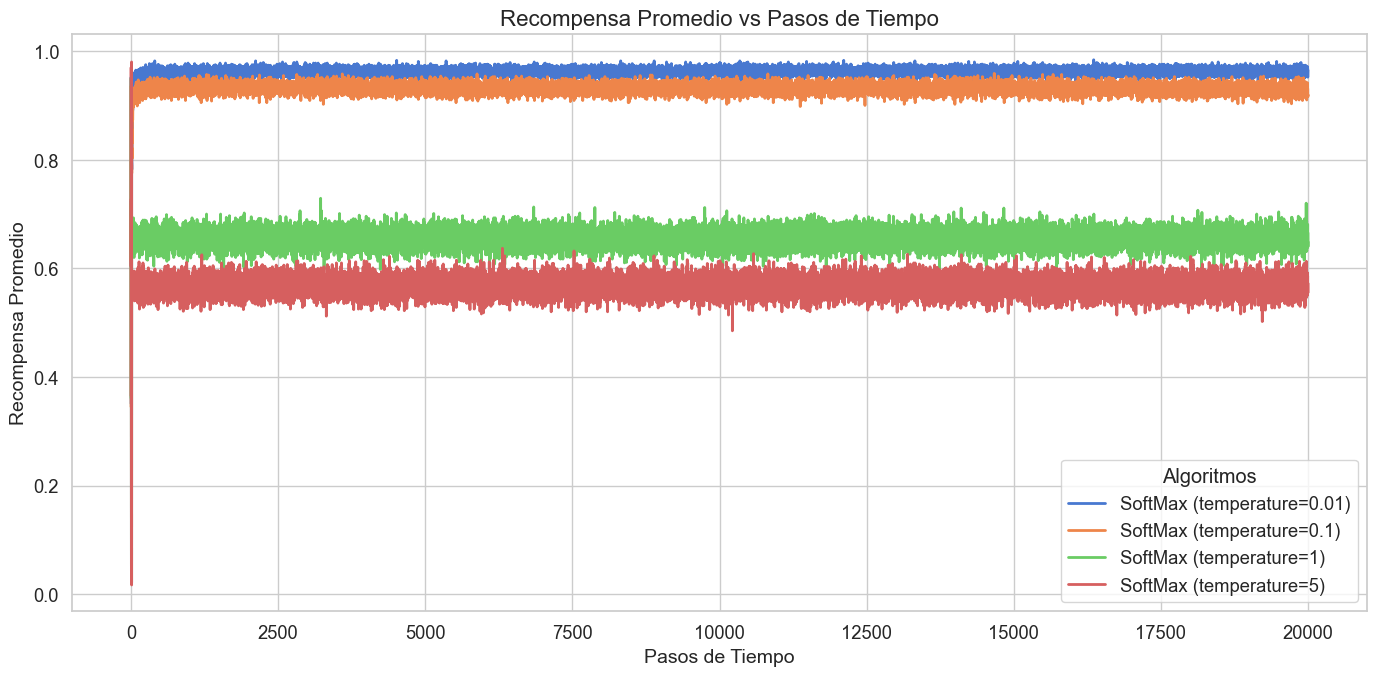

In [6]:
plot_average_rewards(STEPS, rewards_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Para estos brazos aleatorios reproducibles con distribución de Bernoulli, la temperatura 0.1 se acerca más en cuanto a recompensa promedio a la temperatura 0.01 por lo que seguramente los dos mejores brazos tendrán una probabilidad más alejada que en el caso visto con la distribución binomial.

#### Selecciones óptimas

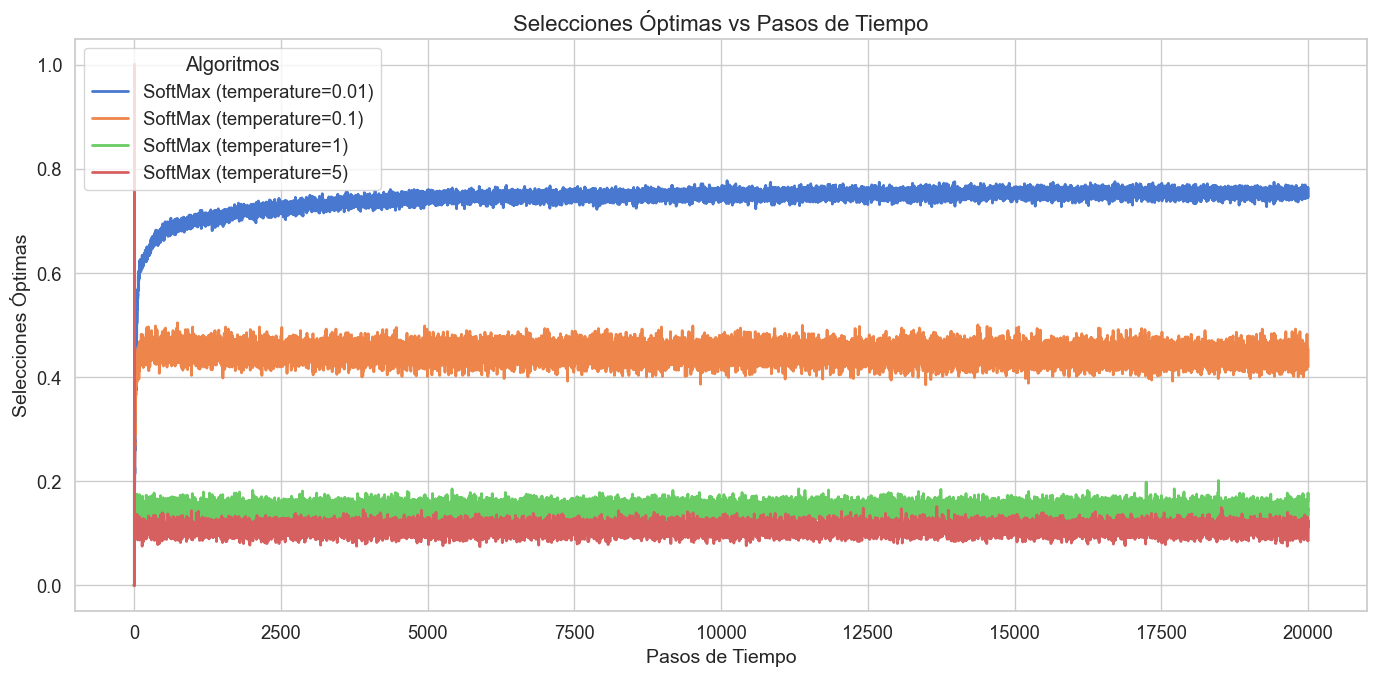

In [7]:
plot_optimal_selections(STEPS, optimal_selections_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

El porcentaje de selecciones óptimas se aleja del 100% en todos los casos. El que mejor porcentaje obtiene es el algoritmo más explotador con un 75% aproximadamente. Esto deja la puerta abierta a la experimentación con valores de explotación mayor para conseguir que el algoritmo se decante un mayor número de veces por la selección óptima.

#### Arrepentimiento

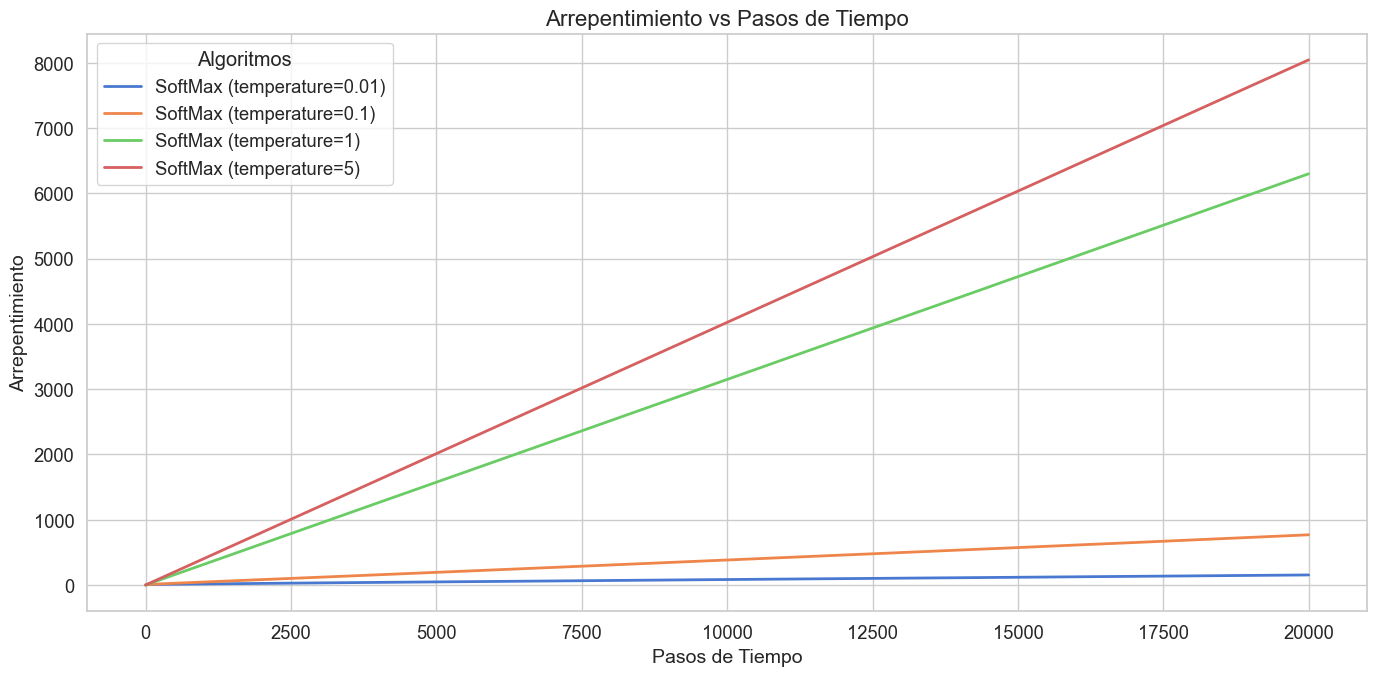

In [8]:
plot_regret(STEPS, regret_accumulated_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

El arrepentimiento acumulado confirma que ninguno de los algoritmos está consiguiendo estabilizar su nivel de arrepentimiento a lo largo del tiempo por lo que todavía no han conseguido llegar a unas probabilidades con la que se explote la opción óptima en la gran mayoría de selecciones.

#### Estadísticas por brazo

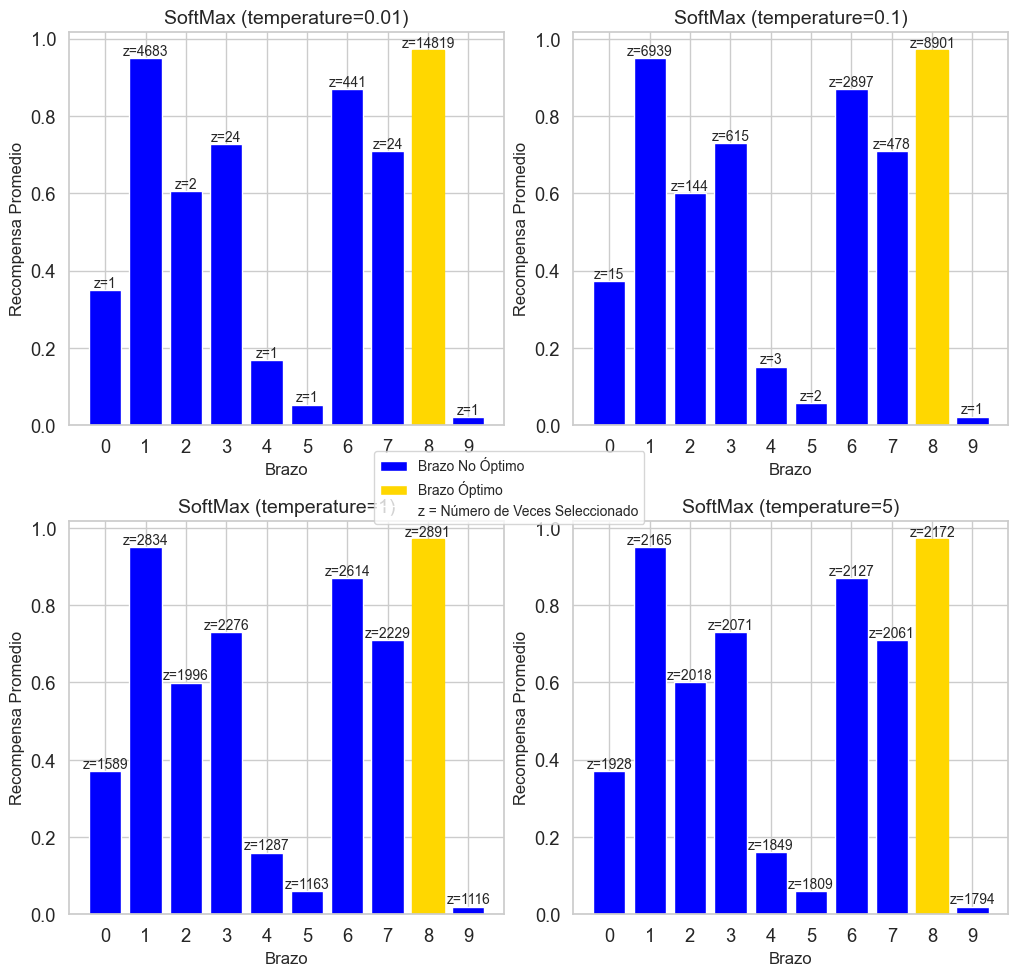

In [9]:
plot_arm_statistics(arm_stats_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Las estadísticas por brazo muestran como los dos mejores brazos son muy próximos en cuanto a recompensa aunque menos próximos que en el caso binomial. De nuevo, todas las configuraciones fueron capaz de elegir el mejor brazo el mayor número de veces.

## Conclusiones

Este experimento y su comparación con el experimento de la distribución binomial se puede concluir que a mayor es la cercanía en la recompensa promedio de los mejores brazos, menor es el nivel de exploración que hay que hacer para conseguir diferenciar dichos brazos.